In [1]:
!pip install -q -r  /kaggle/input/datasets/martinkoome/requirements/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 27.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.

In [2]:
# Imports
import os, cv2, numpy as np, math, pandas as pd, json, glob
import xml.etree.ElementTree as ET
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torchreid import utils
import torchvision
from torchvision.transforms import v2 as T
from torchvision.models.video import r3d_18, R3D_18_Weights
from torchvision.transforms.functional import resize, center_crop, normalize

import warnings 
warnings.filterwarnings("ignore")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
E0000 00:00:1774818878.190248      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774818878.264103      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774818878.937348      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774818878.937404      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774818878.937407      55 computation_placer.cc:177] computation placer already regis

In [3]:
def parse_complete_viper_dataset(file_path):
    namespaces = {'viper': 'http://lamp.cfar.umd.edu/viper#', 'data': 'http://lamp.cfar.umd.edu/viperdata#'}
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return []

    data_records = []
    filename = os.path.basename(file_path)

    # Handle both formats — files with and without the viper default namespace
    ns = root.tag.split('}')[0].strip('{') if '}' in root.tag else None
    if ns == 'http://lamp.cfar.umd.edu/viper#':
        # Working format — use viper namespace prefix 
        target_objects = [d.get('name') for d in root.findall('.//viper:descriptor[@type="OBJECT"]', namespaces)]
        sourcefiles = root.findall('.//viper:sourcefile', namespaces)
        def find_objects(sourcefile, obj_name):
            return sourcefile.findall(f'.//viper:object[@name="{obj_name}"]', namespaces)
        def find_attrs(obj):
            return obj.findall('.//viper:attribute', namespaces)
    else:
        # Failing format — no viper namespace, search without prefix
        target_objects = [d.get('name') for d in root.findall('.//{http://lamp.cfar.umd.edu/viperdata#}..') or root.findall('.//descriptor[@type="OBJECT"]')]
        sourcefiles = root.findall('.//sourcefile')
        def find_objects(sourcefile, obj_name):
            return sourcefile.findall(f'.//object[@name="{obj_name}"]')
        def find_attrs(obj):
            return obj.findall('.//attribute')

    for sourcefile in sourcefiles:
        for obj_name in target_objects:
            for obj in find_objects(sourcefile, obj_name):
                object_id = obj.get('id')
                for attr in find_attrs(obj):
                    geometries = attr.findall('.//data:bbox', namespaces) + attr.findall('.//data:obox', namespaces)
                    for geom in geometries:
                        span = geom.get('framespan', "")
                        for r_span in span.split(' '):
                            if ':' not in r_span: continue
                            start, end = map(int, r_span.split(':'))
                            for frame_num in range(start, end + 1):
                                data_records.append({
                                    'filename': filename, 'object_id': object_id, 'class_label': obj_name, 'frame': frame_num,
                                    'x': int(geom.get('x', 0)), 'y': int(geom.get('y', 0)),
                                    'width': int(geom.get('width', 0)), 'height': int(geom.get('height', 0)),
                                    'area': int(geom.get('width', 0)) * int(geom.get('height', 0))
                                })
    return data_records

In [4]:
DATASET_PATH = '/kaggle/input/datasets/martinkoome/pevid-hd'
xgtf_files = glob.glob(os.path.join(DATASET_PATH, '**', '*.xgtf'), recursive=True)
all_data = []
for file in xgtf_files:
    all_data.extend(parse_complete_viper_dataset(file))

df = pd.DataFrame(all_data)
for col in ['action', 'visibility']:
    if col not in df.columns: df[col] = "unknown"

print(f"Success: Global 'df' defined with {len(df)} entries.")

Success: Global 'df' defined with 44839 entries.


In [3]:
OUTPUT_DIR = Path("analysis_results")
for sub in ["images/pre_an", "images/post_an_clean", "images/post_an_labeled", "videos", "metadata"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

# Addressing Accessory Clustering and Contor Perterbation

In [4]:
import cv2
import json
import math
import glob
import numpy as np
from collections import deque
from pathlib import Path

try:
    from ultralytics import YOLO
except ImportError:
    YOLO = None


class PrivacyAwareRedactionPipeline:
    """
    Privacy-preserving redaction pipeline with:
    - person/accessory association
    - track-level memory
    - contour perturbation
    - temporal smoothing
    - adaptive blur / pixelate / blackout redaction

    Input structure is kept close to your current pipeline:
    - process_frame(frame, pevid_objects, method='blur', frame_idx=0, depth_map=None)
    - run_scene_analysis(scene_name, mode='video', target_frame=150, method='blur')
    """

    def __init__(
        self,
        use_yolo=True,
        model_path="yolov8m-seg.pt",
        conf=0.15,
        alpha_r=4.5,
        alpha_l=0.15,
        k_base=13,
        d_base=4,
        temporal_window=5,
        track_iou_thr=0.20,
        track_max_age=10,
        accessory_merge_iou=0.05,
        accessory_merge_margin=18,
        contour_jitter_px=6,
        contour_scale_jitter=0.03,
        mask_smooth_kernel=5,
        person_classes=None,
        accessory_classes=None,
    ):
        self.use_yolo = use_yolo
        self.model_path = model_path
        self.conf = conf

        self.alpha_r = alpha_r
        self.alpha_l = alpha_l
        self.k_base = k_base
        self.d_base = d_base

        self.temporal_window = temporal_window
        self.track_iou_thr = track_iou_thr
        self.track_max_age = track_max_age

        self.accessory_merge_iou = accessory_merge_iou
        self.accessory_merge_margin = accessory_merge_margin

        self.contour_jitter_px = contour_jitter_px
        self.contour_scale_jitter = contour_scale_jitter
        self.mask_smooth_kernel = mask_smooth_kernel if mask_smooth_kernel % 2 == 1 else mask_smooth_kernel + 1

        self.person_classes = set([c.lower() for c in (person_classes or ["person", "face"])])
        self.accessory_classes = set([c.lower() for c in (accessory_classes or ["backpack", "handbag", "bag", "suitcase", "umbrella", "accessory"])])

        self.model = None
        if self.use_yolo:
            if YOLO is None:
                raise ImportError("ultralytics is not installed. Install it or set use_yolo=False.")
            self.model = YOLO(self.model_path)
            self.model.conf = self.conf

        self.next_track_id = 1
        self.tracks = {}  # track_id -> state dict

    # ---------------------------------------------------------------------
    # Basic geometry helpers
    # ---------------------------------------------------------------------
    def _clip_box(self, box, w_img, h_img):
        x1, y1, x2, y2 = box
        x1 = int(max(0, min(x1, w_img - 1)))
        y1 = int(max(0, min(y1, h_img - 1)))
        x2 = int(max(0, min(x2, w_img - 1)))
        y2 = int(max(0, min(y2, h_img - 1)))
        if x2 <= x1:
            x2 = min(w_img - 1, x1 + 1)
        if y2 <= y1:
            y2 = min(h_img - 1, y1 + 1)
        return np.array([x1, y1, x2, y2], dtype=np.int32)

    def _expand_box(self, box, margin, w_img, h_img):
        x1, y1, x2, y2 = box.astype(np.int32)
        return self._clip_box([x1 - margin, y1 - margin, x2 + margin, y2 + margin], w_img, h_img)

    def _box_area(self, box):
        x1, y1, x2, y2 = box
        return max(0, x2 - x1) * max(0, y2 - y1)

    def _box_iou(self, box_a, box_b):
        ax1, ay1, ax2, ay2 = box_a
        bx1, by1, bx2, by2 = box_b

        ix1 = max(ax1, bx1)
        iy1 = max(ay1, by1)
        ix2 = min(ax2, bx2)
        iy2 = min(ay2, by2)

        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        if inter == 0:
            return 0.0

        area_a = self._box_area(box_a)
        area_b = self._box_area(box_b)
        union = max(area_a + area_b - inter, 1e-6)
        return inter / union

    def _centroid(self, box):
        x1, y1, x2, y2 = box
        return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

    def _mask_from_box(self, shape, box):
        h, w = shape[:2]
        x1, y1, x2, y2 = box.astype(np.int32)
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
        return mask

    def _mask_from_polygon(self, shape, polygon):
        h, w = shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        if polygon is not None and len(polygon) > 0:
            cv2.fillPoly(mask, [polygon.astype(np.int32)], 255)
        return mask

    def _bbox_from_mask(self, mask):
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None
        return np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1], dtype=np.int32)

    # ---------------------------------------------------------------------
    # PRS and redaction
    # ---------------------------------------------------------------------
    def compute_r(self, img_area, obj_area, depth_value=None):
        """
        Area-based PRS remains compatible with your baseline.
        If depth_value is later available, you can extend this easily.
        """
        if depth_value is not None:
            # Nearer subjects => higher risk
            depth_value = max(float(depth_value), 1e-6)
            r = self.alpha_r * math.log(1.0 + (1.0 / depth_value))
            return max(r, 1.0)

        relative_area = (100.0 * float(obj_area)) / max(float(img_area), 1e-6)
        if relative_area <= 0:
            return 1.0

        r = self.alpha_r * math.log(relative_area)
        return max(r, 1.0)

    def apply_filter(self, roi, r, method):
        h, w = roi.shape[:2]
        if h == 0 or w == 0:
            return roi

        max_bound = int(max(self.alpha_l * min(h, w), 1))

        if method == "blur":
            k_a = min(int(r * self.k_base), max_bound)
            if k_a % 2 == 0:
                k_a = max(1, k_a - 1)
            sigma_a = 0.3 * (0.5 * (k_a - 1) - 1) + 0.8
            return cv2.GaussianBlur(roi, (k_a, k_a), sigma_a)

        elif method == "pixelate":
            d_a = min(int(r * self.d_base), max_bound)
            d_a = max(d_a, 1)
            small = cv2.resize(roi, (max(1, w // d_a), max(1, h // d_a)), interpolation=cv2.INTER_LINEAR)
            return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

        elif method == "blackout":
            return np.zeros_like(roi)

        return roi

    def _draw_research_label(self, img, box, name, r, color=(0, 255, 0)):
        x1, y1, x2, y2 = map(int, box)
        label = f"{name} | PRS:{r:.2f}"
        font = cv2.FONT_HERSHEY_DUPLEX
        scale, thick = 0.8, 2
        (tw, th), _ = cv2.getTextSize(label, font, scale, thick)

        y_text = max(y1, th + 20)
        cv2.rectangle(img, (x1, y_text - th - 20), (x1 + tw + 10, y_text), color, -1)
        cv2.putText(img, label, (x1 + 5, y_text - 10), font, scale, (0, 0, 0), thick)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

    # ---------------------------------------------------------------------
    # Detection parsing
    # ---------------------------------------------------------------------
    def _resolve_class_name(self, names, cls_id):
        if isinstance(names, dict):
            return str(names.get(int(cls_id), str(cls_id))).lower()
        if isinstance(names, (list, tuple)) and 0 <= int(cls_id) < len(names):
            return str(names[int(cls_id)]).lower()
        return str(cls_id).lower()

    def _detections_from_yolo(self, frame):
        """
        Returns a list of detections:
        [
          {
            'kind': 'person' or 'accessory' or 'other',
            'class_name': ...,
            'cls_id': ...,
            'conf': ...,
            'box': np.array([x1,y1,x2,y2]),
            'poly': np.array([...]) or None
          },
          ...
        ]
        """
        results = self.model(frame, verbose=False)[0]
        detections = []

        if results.boxes is None or len(results.boxes) == 0:
            return detections

        names = results.names
        masks_xy = results.masks.xy if results.masks is not None else None

        for i in range(len(results.boxes)):
            box = results.boxes.xyxy[i].cpu().numpy().astype(np.int32)
            cls_id = int(results.boxes.cls[i].item())
            conf = float(results.boxes.conf[i].item())
            class_name = self._resolve_class_name(names, cls_id)

            poly = None
            if masks_xy is not None and i < len(masks_xy):
                poly = masks_xy[i].astype(np.int32)

            if class_name in self.person_classes:
                kind = "person"
            elif class_name in self.accessory_classes:
                kind = "accessory"
            else:
                kind = "other"

            detections.append(
                {
                    "kind": kind,
                    "class_name": class_name,
                    "cls_id": cls_id,
                    "conf": conf,
                    "box": box,
                    "poly": poly,
                }
            )

        return detections

    def _detections_from_pevid(self, pevid_objects):
        detections = []
        for obj in pevid_objects:
            x, y, w, h = int(obj["x"]), int(obj["y"]), int(obj["width"]), int(obj["height"])
            class_name = str(obj.get("class_label", "object")).lower()
            box = np.array([x, y, x + w, y + h], dtype=np.int32)

            if class_name in self.person_classes:
                kind = "person"
            elif class_name in self.accessory_classes:
                kind = "accessory"
            else:
                kind = "other"

            detections.append(
                {
                    "kind": kind,
                    "class_name": class_name,
                    "cls_id": -1,
                    "conf": 1.0,
                    "box": box,
                    "poly": None,
                    "object_id": obj.get("object_id", None),
                }
            )
        return detections

    # ---------------------------------------------------------------------
    # Track management
    # ---------------------------------------------------------------------
    def _init_track(self, det, frame_idx):
        tid = self.next_track_id
        self.next_track_id += 1
        self.tracks[tid] = {
            "box": det["box"].copy(),
            "last_frame": frame_idx,
            "missed": 0,
            "hits": 1,
            "prs_history": deque(maxlen=self.temporal_window),
            "mask_history": deque(maxlen=self.temporal_window),
            "centroid": self._centroid(det["box"]),
        }
        return tid

    def _update_track(self, tid, det, frame_idx):
        tr = self.tracks[tid]
        tr["box"] = det["box"].copy()
        tr["last_frame"] = frame_idx
        tr["missed"] = 0
        tr["hits"] += 1
        tr["centroid"] = self._centroid(det["box"])
        return tid

    def _assign_tracks(self, person_dets, frame_idx):
        """
        Greedy IoU matching between current person detections and existing tracks.
        Returns list of (det, track_id).
        """
        assignments = []
        used_tracks = set()

        # Prefer high-confidence / large detections first
        person_dets = sorted(person_dets, key=lambda d: float(d["conf"]), reverse=True)

        for det in person_dets:
            best_tid = None
            best_score = 0.0

            for tid, tr in self.tracks.items():
                if tid in used_tracks:
                    continue
                iou = self._box_iou(det["box"], tr["box"])
                if iou > best_score:
                    best_score = iou
                    best_tid = tid

            if best_tid is not None and best_score >= self.track_iou_thr:
                self._update_track(best_tid, det, frame_idx)
                used_tracks.add(best_tid)
                assignments.append((det, best_tid))
            else:
                tid = self._init_track(det, frame_idx)
                used_tracks.add(tid)
                assignments.append((det, tid))

        # age unmatched tracks
        for tid in list(self.tracks.keys()):
            if tid not in used_tracks:
                self.tracks[tid]["missed"] += 1
                if self.tracks[tid]["missed"] > self.track_max_age:
                    del self.tracks[tid]

        return assignments

    # ---------------------------------------------------------------------
    # Accessory attachment and contour perturbation
    # ---------------------------------------------------------------------
    def _should_attach_accessory(self, person_box, accessory_box, frame_shape):
        h_img, w_img = frame_shape[:2]
        expanded = self._expand_box(person_box, self.accessory_merge_margin, w_img, h_img)
        iou = self._box_iou(person_box, accessory_box)
        if iou >= self.accessory_merge_iou:
            return True

        # if accessory is inside / touching expanded person region, attach it
        ax1, ay1, ax2, ay2 = accessory_box
        ex1, ey1, ex2, ey2 = expanded
        inter = not (ax2 < ex1 or ax1 > ex2 or ay2 < ey1 or ay1 > ey2)
        return inter

    def _attach_accessories(self, person_det, accessory_dets, frame_shape):
        """
        Build a merged mask for one person and all attached accessories.
        """
        h_img, w_img = frame_shape[:2]

        # person mask
        if person_det.get("poly") is not None:
            merged = self._mask_from_polygon(frame_shape, person_det["poly"])
        else:
            merged = self._mask_from_box(frame_shape, person_det["box"])

        attached = []
        for acc in accessory_dets:
            if self._should_attach_accessory(person_det["box"], acc["box"], frame_shape):
                if acc.get("poly") is not None:
                    acc_mask = self._mask_from_polygon(frame_shape, acc["poly"])
                else:
                    acc_mask = self._mask_from_box(frame_shape, acc["box"])
                merged = cv2.bitwise_or(merged, acc_mask)
                attached.append(acc)

        # Expand slightly to cover edges / clothing boundary leakage
        kernel = np.ones((3, 3), np.uint8)
        merged = cv2.dilate(merged, kernel, iterations=1)
        return merged, attached

    def _perturb_contour(self, mask, track_id, frame_idx):
        """
        Slightly distort the silhouette boundary to weaken contour/gait cues.
        """
        if mask is None or mask.sum() == 0:
            return mask

        rng = np.random.default_rng(seed=(track_id * 1000003 + frame_idx * 9176) % (2**32 - 1))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        perturbed = np.zeros_like(mask)

        for cnt in contours:
            if len(cnt) < 3:
                continue

            pts = cnt.reshape(-1, 2).astype(np.float32)
            center = pts.mean(axis=0, keepdims=True)

            # radial + Cartesian jitter
            noise_xy = rng.normal(0, self.contour_jitter_px, size=pts.shape).astype(np.float32)
            scale_noise = rng.normal(0, self.contour_scale_jitter, size=(pts.shape[0], 1)).astype(np.float32)

            vec = pts - center
            pts_new = center + vec * (1.0 + scale_noise) + noise_xy

            pts_new = np.round(pts_new).astype(np.int32)
            cv2.fillPoly(perturbed, [pts_new], 255)

        # Smooth the perturbation to avoid unnatural jagged edges
        k = self.mask_smooth_kernel
        kernel = np.ones((k, k), np.uint8)
        perturbed = cv2.morphologyEx(perturbed, cv2.MORPH_CLOSE, kernel, iterations=1)
        perturbed = cv2.morphologyEx(perturbed, cv2.MORPH_OPEN, kernel, iterations=1)
        perturbed = cv2.dilate(perturbed, np.ones((3, 3), np.uint8), iterations=1)

        return perturbed

    def _temporal_smooth_mask(self, track_id, current_mask):
        tr = self.tracks[track_id]
        tr["mask_history"].append(current_mask.astype(np.uint8))

        stack = np.stack(list(tr["mask_history"]), axis=0).astype(np.float32)
        avg = stack.mean(axis=0)

        # Threshold chosen to balance stability and privacy
        smoothed = (avg >= 0.5).astype(np.uint8) * 255
        return smoothed

    def _temporal_smooth_prs(self, track_id, prs_value):
        tr = self.tracks[track_id]
        tr["prs_history"].append(float(prs_value))
        return float(np.mean(tr["prs_history"]))

    # ---------------------------------------------------------------------
    # Main frame processing
    # ---------------------------------------------------------------------
    def process_frame(self, frame, pevid_objects=None, method="blur", frame_idx=0, depth_map=None):
        h_img, w_img = frame.shape[:2]
        img_area = h_img * w_img

        clean = frame.copy()
        labeled = frame.copy()
        meta_dict = {}

        # -------------------------------------------------------------
        # 1) Detect objects
        # -------------------------------------------------------------
        if self.use_yolo:
            detections = self._detections_from_yolo(frame)
        else:
            detections = self._detections_from_pevid(pevid_objects or [])

        person_dets = [d for d in detections if d["kind"] == "person"]
        accessory_dets = [d for d in detections if d["kind"] == "accessory"]

        # -------------------------------------------------------------
        # 2) Track persons across time
        # -------------------------------------------------------------
        assignments = self._assign_tracks(person_dets, frame_idx)

        # Keep accessory detections available for merging
        used_accessories = set()

        # -------------------------------------------------------------
        # 3) Build merged mask per person track
        # -------------------------------------------------------------
        for det, track_id in assignments:
            merged_mask, attached = self._attach_accessories(det, accessory_dets, frame.shape)

            # mark attached accessories so we don't double count later
            for acc in attached:
                used_accessories.add(id(acc))

            # contour perturbation
            perturbed_mask = self._perturb_contour(merged_mask, track_id, frame_idx)

            # temporal smoothing to reduce flicker and stabilize gait handling
            final_mask = self._temporal_smooth_mask(track_id, perturbed_mask)

            bbox = self._bbox_from_mask(final_mask)
            if bbox is None:
                # fallback to original person box
                bbox = det["box"].copy()

            # adaptive PRS from merged mask area
            merged_area = int(np.sum(final_mask > 0))
            depth_value = None
            if depth_map is not None:
                # optional future extension: median depth inside final mask
                ys, xs = np.where(final_mask > 0)
                if len(xs) > 0:
                    vals = depth_map[ys, xs]
                    vals = vals[np.isfinite(vals)]
                    if len(vals) > 0:
                        depth_value = float(np.median(vals))

            prs = self.compute_r(img_area, merged_area, depth_value=depth_value)
            prs = self._temporal_smooth_prs(track_id, prs)

            x1, y1, x2, y2 = bbox
            x1, y1, x2, y2 = self._clip_box([x1, y1, x2, y2], w_img, h_img)

            roi = frame[y1:y2, x1:x2]
            if roi.size == 0:
                continue

            redacted_roi = self.apply_filter(roi, prs, method)

            # Paste only within the final mask
            mask_roi = final_mask[y1:y2, x1:x2]
            if mask_roi.shape[:2] != redacted_roi.shape[:2]:
                continue

            clean[y1:y2, x1:x2][mask_roi == 255] = redacted_roi[mask_roi == 255]
            labeled[y1:y2, x1:x2][mask_roi == 255] = redacted_roi[mask_roi == 255]

            name = f"Person_T{track_id}"
            self._draw_research_label(labeled, bbox, name, prs)

            meta_dict[f"track_{track_id}"] = {
                "name": name,
                "prs": round(float(prs), 3),
                "merged_area": int(merged_area),
                "box": bbox.tolist(),
                "attached_accessories": len(attached),
                "method": method,
            }

        # -------------------------------------------------------------
        # 4) Optional: if you want to log accessories too
        # -------------------------------------------------------------
        accessory_count = len(accessory_dets)
        meta_dict["frame_summary"] = {
            "persons": len(person_dets),
            "accessories_detected": accessory_count,
            "frame_idx": int(frame_idx),
        }

        return clean, labeled, meta_dict

    # ---------------------------------------------------------------------
    # Scene / video runner with the same style as your current code
    # ---------------------------------------------------------------------
    def run_scene_analysis(
        self,
        scene_name,
        dataset_path,
        output_dir,
        df,
        mode="video",
        target_frame=150,
        method="blur",
        video_ext=".mpg",
    ):
        if df is None or "filename" not in df.columns:
            print("Error: DataFrame df is missing or does not contain a 'filename' column.")
            return

        target_filename = f"{scene_name}.xgtf"
        if target_filename not in df["filename"].unique():
            print(f"Error: Scene '{target_filename}' not found in df.")
            return

        scene_df = df[df["filename"] == target_filename].sort_values("frame").copy()
        if "area" in scene_df.columns:
            scene_df["proc_area"] = scene_df.groupby("object_id")["area"].transform(
                lambda x: x.rolling(self.temporal_window, min_periods=1).mean()
            )

        video_files = glob.glob(str(Path(dataset_path) / "**" / f"{scene_name}{video_ext}"), recursive=True)
        if not video_files:
            print(f"Error: Video {scene_name}{video_ext} not found.")
            return

        cap = cv2.VideoCapture(video_files[0])
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        sample_interval = max(1, total_frames // 10)

        output_dir = Path(output_dir)
        (output_dir / "videos").mkdir(parents=True, exist_ok=True)
        (output_dir / "images" / "pre_an").mkdir(parents=True, exist_ok=True)
        (output_dir / "images" / "post_an_clean").mkdir(parents=True, exist_ok=True)
        (output_dir / "images" / "post_an_labeled").mkdir(parents=True, exist_ok=True)
        (output_dir / "metadata").mkdir(parents=True, exist_ok=True)

        out_clean = None
        out_labeled = None
        if mode == "video":
            out_clean = cv2.VideoWriter(
                str(output_dir / "videos" / f"{scene_name}_{method}_clean.mp4"),
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                (w, h),
            )
            out_labeled = cv2.VideoWriter(
                str(output_dir / "videos" / f"{scene_name}_{method}_labeled.mp4"),
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                (w, h),
            )

        full_log = {}
        frame_idx = 1

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            if mode == "image" and frame_idx != target_frame:
                frame_idx += 1
                continue

            current_objs = scene_df[scene_df["frame"] == frame_idx].to_dict("records")
            clean, labeled, meta = self.process_frame(
                frame,
                pevid_objects=current_objs,
                method=method,
                frame_idx=frame_idx,
            )

            if (frame_idx == target_frame) or (mode == "video" and frame_idx % sample_interval == 0):
                cv2.imwrite(str(output_dir / "images" / "pre_an" / f"{scene_name}_f{frame_idx}.jpg"), frame)
                cv2.imwrite(str(output_dir / "images" / "post_an_clean" / f"{scene_name}_{method}_f{frame_idx}.jpg"), clean)
                cv2.imwrite(str(output_dir / "images" / "post_an_labeled" / f"{scene_name}_{method}_f{frame_idx}.jpg"), labeled)

            if mode == "video":
                out_clean.write(clean)
                out_labeled.write(labeled)
                full_log[frame_idx] = meta

            if mode == "image" and frame_idx == target_frame:
                break

            frame_idx += 1

        cap.release()
        if out_clean is not None:
            out_clean.release()
        if out_labeled is not None:
            out_labeled.release()

        with open(output_dir / "metadata" / f"{scene_name}_{method}.json", "w") as f:
            json.dump(full_log, f, indent=4)

        print(f"Handoff complete for {scene_name}. Samples saved for automated audit.")

In [5]:
pipeline = PrivacyAwareRedactionPipeline(
    use_yolo=True,
    model_path="yolov8m-seg.pt",
    conf=0.15,
    alpha_r=4.5,
    alpha_l=0.15,
    temporal_window=5,
    accessory_merge_margin=18,
    contour_jitter_px=6,
)

In [9]:
pipeline.run_scene_analysis(
    scene_name="stealing_night_outdoor_1_2",
    dataset_path=DATASET_PATH,
    output_dir=OUTPUT_DIR,
    df=df,
    mode="video",
    target_frame=200,
    method="pixelate",
    video_ext=".mpg",
)

Handoff complete for stealing_night_outdoor_1_2. Samples saved for automated audit.


In [10]:
pipeline.run_scene_analysis(
    scene_name="fighting_day_indoor_4_1",
    dataset_path=DATASET_PATH,
    output_dir=OUTPUT_DIR,
    df=df,
    mode="video",
    target_frame=200,
    method="blackout",
    video_ext=".mpg",
)

Handoff complete for fighting_day_indoor_4_1. Samples saved for automated audit.


In [30]:
frame = cv2.imread("/kaggle/working/analysis_results/images/pre_an/fighting_day_indoor_4_1_f160.jpg")

current_objs = [
    {"object_id": 1, "class_label": "person", "x": 100, "y": 60, "width": 80, "height": 200},
    {"object_id": 2, "class_label": "backpack", "x": 120, "y": 140, "width": 40, "height": 60},
]

clean, labeled, meta = pipeline.process_frame(
    frame,
    pevid_objects=current_objs,
    method="blackout",
    frame_idx=1,
)

In [31]:
comparison = np.hstack([frame, clean, labeled])
cv2.imwrite("comparison.jpg", comparison)
del comparison

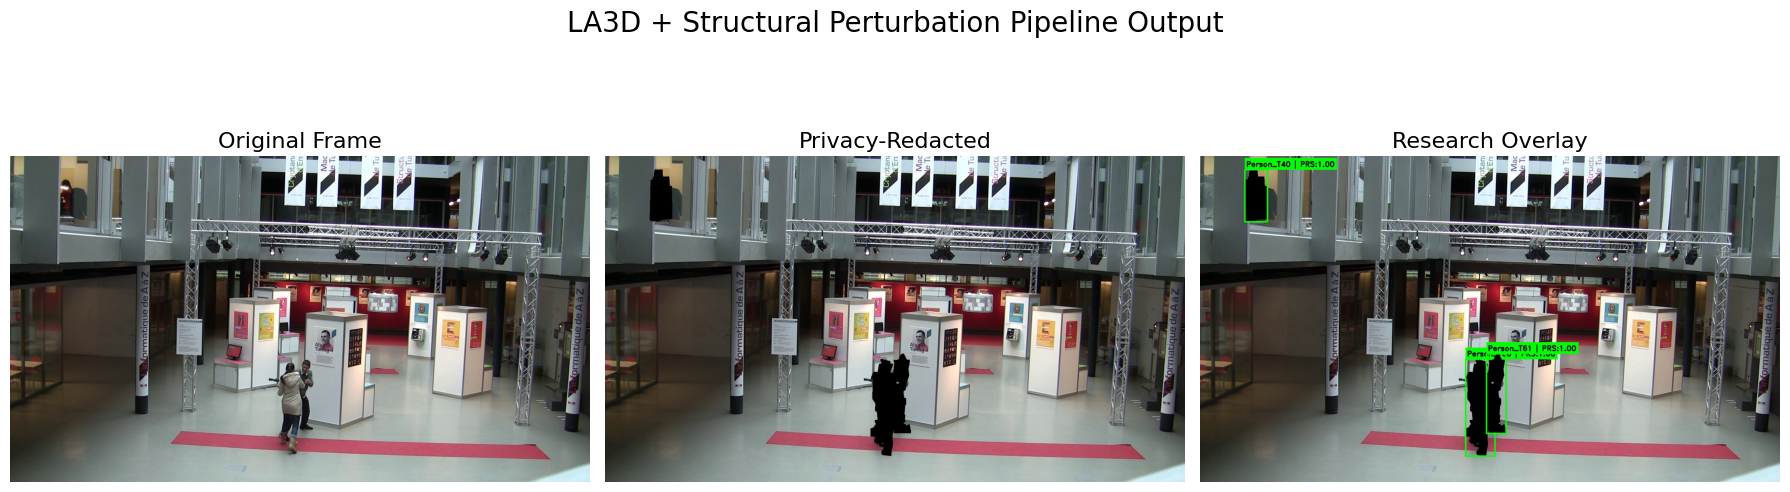

In [32]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/working/comparison.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img_rgb.shape
third = w // 3

# Split the image into 3 panels
original = img_rgb[:, :third]
redacted = img_rgb[:, third:2*third]
overlay  = img_rgb[:, 2*third:]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(original)
axes[0].set_title("Original Frame", fontsize=16)
axes[0].axis("off")

axes[1].imshow(redacted)
axes[1].set_title("Privacy-Redacted", fontsize=16)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Research Overlay", fontsize=16)
axes[2].axis("off")

fig.suptitle("LA3D + Structural Perturbation Pipeline Output", fontsize=20)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
frame = cv2.imread("/kaggle/working/analysis_results/images/pre_an/fighting_day_indoor_4_1_f160.jpg")

current_objs = [
    {"object_id": 1, "class_label": "person", "x": 100, "y": 60, "width": 80, "height": 200},
    {"object_id": 2, "class_label": "backpack", "x": 120, "y": 140, "width": 40, "height": 60},
]

clean, labeled, meta = pipeline.process_frame(
    frame,
    pevid_objects=current_objs,
    method="blackout",
    frame_idx=1,
)

In [ ]:
comparison = np.hstack([frame, clean, labeled])
cv2.imwrite("comparison.jpg", comparison)
del comparison

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/working/comparison.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img_rgb.shape
third = w // 3

# Split the image into 3 panels
original = img_rgb[:, :third]
redacted = img_rgb[:, third:2*third]
overlay  = img_rgb[:, 2*third:]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(original)
axes[0].set_title("Original Frame", fontsize=16)
axes[0].axis("off")

axes[1].imshow(redacted)
axes[1].set_title("Privacy-Redacted", fontsize=16)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Research Overlay", fontsize=16)
axes[2].axis("off")

fig.suptitle("LA3D + Structural Perturbation Pipeline Output", fontsize=20)
plt.tight_layout()
plt.show()
plt.close()